In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Windows 기본 한글 폰트 (맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


# Dataset Info.

### Onlinesales_info.csv [파일]
- 온라인거래와 관련된 정보
- 고객ID : 고객 고유 ID
- 거래ID : 거래 고유 ID
- 거래날짜 : 거래가 이루어진 날짜
- 제품ID : 제품 고유 ID
- 제품카테고리 : 제품이 포함된 카테고리
- 수량 : 주문한 품목 수
- 평균금액 : 수량 1개당 가격 (단위 : 달러)
- 동일 상품이어도 세부 옵션에 따라 가격이 다를 수 있음
- 배송료 : 배송비용 (단위 : 달러)
- 쿠폰상태 : 할인쿠폰 적용 상태


### Customer_info.csv [파일]
- 고객과 관련된 정보
- 고객ID : 고객 고유 ID
- 성별 : 고객 성별
- 고객지역 : 고객지역
- 가입기간 : 가입기간 (단위 : 월)


### Discount_info.csv [파일]
- 할인과 관련된 정보
- 월 : 월(Month) 정보
- 제품카테고리 : 제품이 포함된 카테고리
- 쿠폰코드 : 쿠폰코드
- 할인율 : 해당 쿠폰에 대한 할인율(%)


### Marketing_info.csv [파일]
- 마케팅비용과 관련된 정보
- 날짜 : 마케팅이 이루어진 날짜
- 오프라인비용 : 오프라인 마케팅으로 지출한 비용 (단위 : 달러)
- 온라인비용 : 온라인 마케팅으로 지출한 비용 (단위 : 달러)


### Tax_info.csv [파일]
- 세금과 관련된 정보
- 제품 카테고리 : 제품이 포함된 카테고리
- GST : Goods and Services Tax(%)


In [3]:
tax = pd.read_csv('./data/Tax_info.csv')
onlinesales = pd.read_csv('./data/Onlinesales_info.csv')
marketinginfo = pd.read_csv('./data/Marketing_info.csv')
discountinfo = pd.read_csv('./data/Discount_info.csv')
customerinfo = pd.read_csv('./data/Customer_info.csv')

In [4]:
tax.head()

,제품카테고리,GST
0,Nest-USA,0.10
1,Office,0.10
2,Apparel,0.18
3,Bags,0.18
4,Drinkware,0.18


In [5]:
onlinesales.head()

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used
3,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used
4,USER_1358,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used


In [6]:
marketinginfo.head()

,날짜,오프라인비용,온라인비용
0,2019-01-01,4500,2424.50
1,2019-01-02,4500,3480.36
2,2019-01-03,4500,1576.38
3,2019-01-04,4500,2928.55
4,2019-01-05,4500,4055.30


In [7]:
discountinfo.head()

,월,제품카테고리,쿠폰코드,할인율
0,Jan,Apparel,SALE10,10
1,Feb,Apparel,SALE20,20
2,Mar,Apparel,SALE30,30
3,Jan,Nest-USA,ELEC10,10
4,Feb,Nest-USA,ELEC20,20


In [8]:
customerinfo.head()

,고객ID,성별,고객지역,가입기간
0,USER_1358,남,Chicago,12
1,USER_0190,남,California,43
2,USER_0066,남,Chicago,33
3,USER_0345,여,California,30
4,USER_0683,남,California,49


In [9]:
customerinfo['고객지역'].value_counts()

고객지역
California       464
Chicago          456
New York         324
New Jersey       149
Washington DC     75
Name: count, dtype: int64

# 성별 분석

In [10]:
# 성별 어떤 제품의 카테고리를 많이 구매하는지 분석
customer_sales = pd.merge(onlinesales, customerinfo, on = "고객ID")
customer_sales.head()

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,성별,고객지역,가입기간
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,남,Chicago,12
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,남,Chicago,12
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,남,Chicago,12
3,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used,남,Chicago,12
4,USER_1358,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used,남,Chicago,12


In [11]:
customer_sales[customer_sales['제품카테고리'] =='Apparel']

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,성별,고객지역,가입기간
3,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used,남,Chicago,12
12,USER_0190,Transaction_0003,2019-01-01,Product_1025,Apparel,5,17.53,6.5,Used,남,California,43
15,USER_0190,Transaction_0005,2019-01-01,Product_0310,Apparel,1,14.02,6.5,Used,남,California,43
16,USER_0190,Transaction_0005,2019-01-01,Product_0486,Apparel,1,14.02,6.5,Clicked,남,California,43
31,USER_0066,Transaction_0010,2019-01-01,Product_0677,Apparel,1,61.89,6.5,Clicked,남,Chicago,33
...,...,...,...,...,...,...,...,...,...,...,...,...
52906,USER_0167,Transaction_25048,2019-12-31,Product_0448,Apparel,4,3.47,6.5,Clicked,여,Chicago,48
52907,USER_0167,Transaction_25048,2019-12-31,Product_0490,Apparel,4,3.47,6.5,Used,여,Chicago,48
52911,USER_0845,Transaction_25052,2019-12-31,Product_0490,Apparel,1,3.47,6.5,Used,남,New Jersey,19
52912,USER_0845,Transaction_25052,2019-12-31,Product_0754,Apparel,1,16.30,6.5,Used,남,New Jersey,19


In [12]:
# 남자인 고객과 여자인 고객의 수
customer_sales['성별'].value_counts()

성별
여    33007
남    19917
Name: count, dtype: int64

In [13]:
# 성별로 어떤 제품 카테고리를 구매했는가
gender_category = (
    customer_sales
    .groupby(['성별', '제품카테고리'])
    .size()
    .reset_index(name = "count")
)
gender_category.head()

,성별,제품카테고리,count
0,남,Accessories,91
1,남,Android,17
2,남,Apparel,6771
3,남,Backpacks,43
4,남,Bags,700


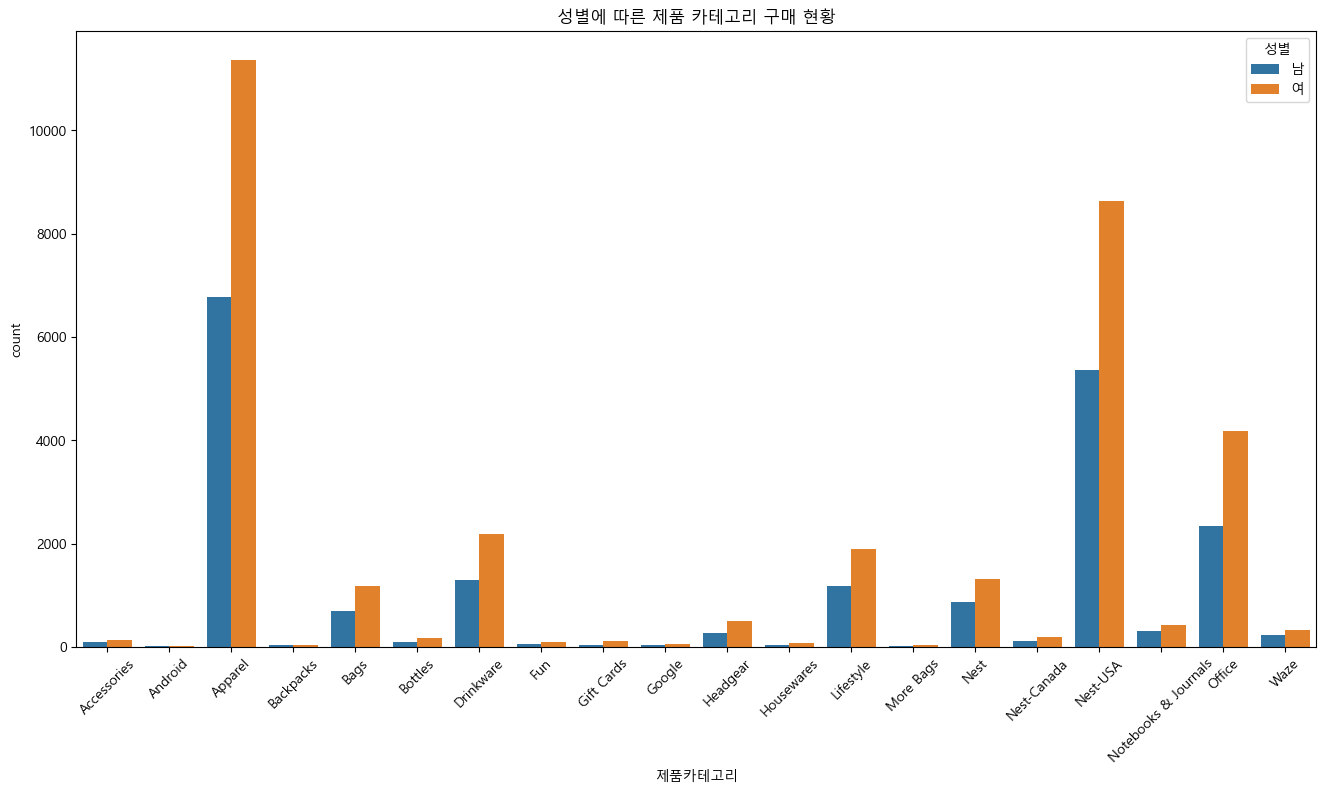

In [14]:
# 여자가 구매량이 훨씬 많고 또한 제품 별로 남자가 더 많이 구매한 제품이 없음
plt.figure(figsize = (16,8))
sns.barplot(
    data = gender_category,
    x = '제품카테고리',
    y = "count",
    hue = "성별"
)
plt.xticks(rotation = 45)
plt.title("성별에 따른 제품 카테고리 구매 현황")
plt.show()

In [15]:
# 제품 카테고리별 평균 금액
category_price = customer_sales.groupby(['제품카테고리', '평균금액']).size().reset_index(name="price")
category_price.head()

,제품카테고리,평균금액,price
0,Accessories,2.39,57
1,Accessories,2.44,17
2,Accessories,2.99,22
3,Accessories,3.05,13
4,Accessories,3.99,42


In [16]:
# 제품카테고리가 Apparel인 데이터는 가격이 다 같지 않음
category_price[category_price['제품카테고리'] == 'Apparel']

,제품카테고리,평균금액,price
26,Apparel,1.59,2
27,Apparel,3.40,66
28,Apparel,3.47,98
29,Apparel,3.80,41
30,Apparel,3.87,37
...,...,...,...
280,Apparel,115.53,2
281,Apparel,119.99,2
282,Apparel,123.79,3
283,Apparel,139.99,1


In [17]:
category_price[category_price['제품카테고리'] == 'Accessories']

,제품카테고리,평균금액,price
0,Accessories,2.39,57
1,Accessories,2.44,17
2,Accessories,2.99,22
3,Accessories,3.05,13
4,Accessories,3.99,42
5,Accessories,4.07,10
6,Accessories,4.99,13
7,Accessories,5.09,12
8,Accessories,13.59,15
9,Accessories,13.85,2


In [18]:
category_price[category_price['제품카테고리'] == 'Nest-USA']

,제품카테고리,평균금액,price
641,Nest-USA,19.19,1
642,Nest-USA,79.00,1937
643,Nest-USA,80.52,255
644,Nest-USA,81.50,215
645,Nest-USA,99.00,21
646,Nest-USA,102.13,28
647,Nest-USA,119.00,5127
648,Nest-USA,121.30,610
649,Nest-USA,122.77,713
650,Nest-USA,149.00,3712
